## 0. Source de dataset

https://www.kaggle.com/datasets/whats2000/human-screaming-detection-dataset

https://www.kaggle.com/datasets/fangfangz/audio-based-violence-detection-dataset

https://github.com/karolpiczak/ESC-50

## 1. Imports

In [2]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf
import collections
import pandas as pd
import shutil

print("✅ Imports OK")

✅ Imports OK


## 2. Chemins

In [3]:
BASE = r"C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet"

# V1 - SESA
SCREAMING_PATH    = os.path.join(BASE, "V1", "data", "SESA", "Screaming")
NOTSCREAMING_PATH = os.path.join(BASE, "V1", "data", "SESA", "NotScreaming")

# V2 - Violence
VIOLENCE_PATH     = os.path.join(BASE, "V2", "data", "VIOLENCE", "violence")
NONVIOLENCE_PATH  = os.path.join(BASE, "V2", "data", "VIOLENCE", "non-violence")

# V3 - ESC-50
ESC50_AUDIO_PATH  = os.path.join(BASE, "V3", "ESC-50-master", "audio")
ESC50_META_PATH   = os.path.join(BASE, "V3", "ESC-50-master", "meta", "esc50.csv")

# Vérifier que tous les chemins existent
for nom, chemin in [
    ("SESA Screaming",    SCREAMING_PATH),
    ("SESA NotScreaming", NOTSCREAMING_PATH),
    ("Violence",          VIOLENCE_PATH),
    ("Non-violence",      NONVIOLENCE_PATH),
    ("ESC-50 audio",      ESC50_AUDIO_PATH),
    ("ESC-50 meta",       ESC50_META_PATH),
]:
    status = "✅" if os.path.exists(chemin) else "❌"
    print(f"{status} {nom}: {chemin}")

✅ SESA Screaming: C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V1\data\SESA\Screaming
✅ SESA NotScreaming: C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V1\data\SESA\NotScreaming
✅ Violence: C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V2\data\VIOLENCE\violence
✅ Non-violence: C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V2\data\VIOLENCE\non-violence
✅ ESC-50 audio: C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V3\ESC-50-master\audio
✅ ESC-50 meta: C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V3\ESC-50-master\meta\esc50.csv


## 3. Fonction extract_mel

In [4]:
def extract_mel(file_path, max_len=128, n_mels=128, sr=22050):
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=5.0)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        if mel_db.shape[1] < max_len:
            mel_db = np.pad(mel_db, ((0,0),(0, max_len - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :max_len]
        return mel_db
    except Exception as e:
        print(f"Erreur sur {file_path}: {e}")
        return None

print("✅ Fonction extract_mel prête")

✅ Fonction extract_mel prête


## 4. Charger SESA

In [5]:
X_danger_sesa, X_normal_sesa = [], []

print("⏳ Chargement SESA Screaming...")
for f in os.listdir(SCREAMING_PATH):
    if f.endswith('.wav') or f.endswith('.mp3'):
        mel = extract_mel(os.path.join(SCREAMING_PATH, f))
        if mel is not None:
            X_danger_sesa.append(mel)

print("⏳ Chargement SESA NotScreaming...")
for f in os.listdir(NOTSCREAMING_PATH):
    if f.endswith('.wav') or f.endswith('.mp3'):
        mel = extract_mel(os.path.join(NOTSCREAMING_PATH, f))
        if mel is not None:
            X_normal_sesa.append(mel)

print(f"\n✅ SESA chargé !")
print(f"🔴 DANGER (Screaming)    : {len(X_danger_sesa)}")
print(f"🟢 NORMAL (NotScreaming) : {len(X_normal_sesa)}")

⏳ Chargement SESA Screaming...
⏳ Chargement SESA NotScreaming...

✅ SESA chargé !
🔴 DANGER (Screaming)    : 862
🟢 NORMAL (NotScreaming) : 2631


## 5. Charger Violence dataset

In [6]:
X_fight, X_noviolence = [], []

print("⏳ Chargement Violence...")
for f in os.listdir(VIOLENCE_PATH):
    if f.endswith('.wav') or f.endswith('.mp3'):
        mel = extract_mel(os.path.join(VIOLENCE_PATH, f))
        if mel is not None:
            X_fight.append(mel)

print("⏳ Chargement Non-violence...")
for f in os.listdir(NONVIOLENCE_PATH):
    if f.endswith('.wav') or f.endswith('.mp3'):
        mel = extract_mel(os.path.join(NONVIOLENCE_PATH, f))
        if mel is not None:
            X_noviolence.append(mel)

print(f"\n✅ Violence dataset chargé !")
print(f"🟠 FIGHT       : {len(X_fight)}")
print(f"🟢 NON-VIOLENCE: {len(X_noviolence)}")

⏳ Chargement Violence...
⏳ Chargement Non-violence...

✅ Violence dataset chargé !
🟠 FIGHT       : 127
🟢 NON-VIOLENCE: 4


## 6. Charger ESC-50 sons normaux variés

In [14]:
# Catégories normales à inclure
categories_normales = [
    'laughing',        # rires
    'clapping',        # applaudissements
    'crying_baby',     # pleurs bébé
    'sneezing',        # éternuements
    'breathing',       # respiration
    'coughing',        # toux
    'footsteps',       # pas
    'door_wood_knock', # coups à la porte
    'keyboard_typing', # clavier
    'clock_alarm',     # réveil
    'chirping_birds',  # oiseaux
    'rain',            # pluie
    'wind',            # vent
    'crackling_fire',  # feu
    'water_drops',     # eau
]

# Charger les métadonnées
meta = pd.read_csv(ESC50_META_PATH)
print(f"Catégories disponibles dans ESC-50 :")
print(sorted(meta['category'].unique()))

Catégories disponibles dans ESC-50 :
['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']


## 7. Extraire les sons normaux ESC-50

In [8]:
# Filtrer les catégories normales disponibles
categories_disponibles = [c for c in categories_normales 
                          if c in meta['category'].values]
print(f"✅ Catégories trouvées : {categories_disponibles}")

normal_meta = meta[meta['category'].isin(categories_disponibles)]
print(f"📊 Total fichiers normaux ESC-50 : {len(normal_meta)}")

# Charger les Mel-Spectrogrammes
X_esc50_normal = []
erreurs = 0

for _, row in normal_meta.iterrows():
    file_path = os.path.join(ESC50_AUDIO_PATH, row['filename'])
    if os.path.exists(file_path):
        mel = extract_mel(file_path)
        if mel is not None:
            X_esc50_normal.append(mel)
    else:
        erreurs += 1

print(f"\n✅ ESC-50 sons normaux chargés : {len(X_esc50_normal)}")
print(f"⚠️ Fichiers non trouvés       : {erreurs}")

✅ Catégories trouvées : ['laughing', 'clapping', 'crying_baby', 'sneezing', 'breathing', 'coughing', 'footsteps', 'door_wood_knock', 'keyboard_typing', 'clock_alarm', 'chirping_birds', 'rain', 'wind', 'crackling_fire', 'water_drops']
📊 Total fichiers normaux ESC-50 : 600

✅ ESC-50 sons normaux chargés : 600
⚠️ Fichiers non trouvés       : 0


## 8. Construire le dataset final

In [9]:
# Convertir en numpy avec dimension canal
X_danger_sesa_np  = np.array(X_danger_sesa)[..., np.newaxis]
X_normal_sesa_np  = np.array(X_normal_sesa)[..., np.newaxis]
X_fight_np        = np.array(X_fight)[..., np.newaxis]
X_noviolence_np   = np.array(X_noviolence)[..., np.newaxis]
X_esc50_normal_np = np.array(X_esc50_normal)[..., np.newaxis]

# DANGER = SESA Screaming + Violence
X_danger_final = np.vstack([X_danger_sesa_np, X_fight_np])

# NORMAL = SESA NotScreaming + Non-violence + ESC-50 varié
X_normal_final = np.vstack([X_normal_sesa_np, 
                             X_noviolence_np, 
                             X_esc50_normal_np])

print("=== Composition du dataset V3 ===")
print(f"🔴 DANGER  = SESA({len(X_danger_sesa_np)}) + Fight({len(X_fight_np)})")
print(f"           = {len(X_danger_final)} total")
print(f"🟢 NORMAL  = SESA({len(X_normal_sesa_np)}) + NonViolence({len(X_noviolence_np)}) + ESC50({len(X_esc50_normal_np)})")
print(f"           = {len(X_normal_final)} total")

# Rééquilibrer
min_size = min(len(X_normal_final), len(X_danger_final))
X_normal_balanced = resample(X_normal_final, n_samples=min_size, random_state=42)
X_danger_balanced = resample(X_danger_final, n_samples=min_size, random_state=42)

X_balanced_v3 = np.vstack([X_normal_balanced, X_danger_balanced])
y_balanced_v3 = np.array([0]*min_size + [1]*min_size)

print(f"\n=== Dataset V3 Final ===")
print(f"🟢 NORMAL : {sum(y_balanced_v3 == 0)}")
print(f"🔴 DANGER : {sum(y_balanced_v3 == 1)}")
print(f"✅ Total  : {len(X_balanced_v3)}")

=== Composition du dataset V3 ===
🔴 DANGER  = SESA(862) + Fight(127)
           = 989 total
🟢 NORMAL  = SESA(2631) + NonViolence(4) + ESC50(600)
           = 3235 total

=== Dataset V3 Final ===
🟢 NORMAL : 989
🔴 DANGER : 989
✅ Total  : 1978


## 9. Entraîner le modèle

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced_v3, y_balanced_v3,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced_v3
)

print(f"✅ Train : {len(X_train)}")
print(f"✅ Test  : {len(X_test)}")

model_v3 = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),
    layers.Conv2D(64, (3,3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),
    layers.Conv2D(128, (3,3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_v3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model_v3.keras", save_best_only=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history_v3 = model_v3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

✅ Train : 1582
✅ Test  : 396



Epoch 1/50


99/99 [==============================] - ETA: 0s - loss: 0.8226 - accuracy: 0.5683 - auc: 0.5954
Epoch 1: val_loss improved from inf to 0.99975, saving model to best_model_v3.keras
99/99 [==============================] - 29s 260ms/step - loss: 0.8226 - accuracy: 0.5683 - auc: 0.5954 - val_loss: 0.9998 - val_accuracy: 0.5152 - val_auc: 0.6263 - lr: 0.0010
Epoch 2/50
99/99 [==============================] - ETA: 0s - loss: 0.7313 - accuracy: 0.6764 - auc: 0.7232
Epoch 2: val_loss improved from 0.99975 to 0.91165, saving model to best_model_v3.keras
99/99 [==============================] - 24s 247ms/step - loss: 0.7313 - accuracy: 0.6764 - auc: 0.7232 - val_loss: 0.9117 - val_accuracy: 0.5202 - val_auc: 0.7340 - lr: 0.0010
Epoch 3/50
99/99 [==============================] - ETA: 0s - loss: 0.6788 - accuracy: 0.6972 - auc: 0.7714
Epoch 3: val_loss did not improve from 0.91165
99/99 [==============================] - 24s 241ms/step - loss: 0.678

## 10. Évaluation

13/13 [==============================] - 2s 110ms/step
=== Résultats V3 ===
              precision    recall  f1-score   support

      NORMAL       0.68      0.93      0.79       198
      DANGER       0.89      0.57      0.70       198

    accuracy                           0.75       396
   macro avg       0.79      0.75      0.74       396
weighted avg       0.79      0.75      0.74       396



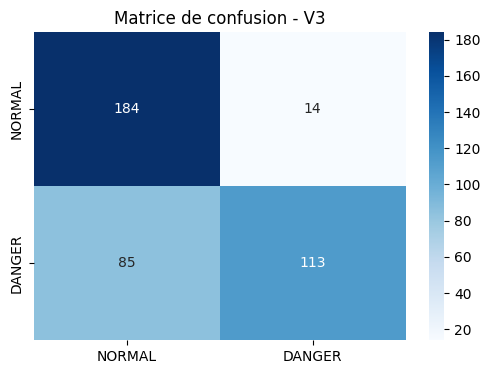

In [11]:
y_pred_v3 = (model_v3.predict(X_test) > 0.5).astype(int)

print("=== Résultats V3 ===")
print(classification_report(y_test, y_pred_v3,
      target_names=["NORMAL", "DANGER"]))

cm = confusion_matrix(y_test, y_pred_v3)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["NORMAL", "DANGER"],
            yticklabels=["NORMAL", "DANGER"],
            cmap="Blues")
plt.title("Matrice de confusion - V3")
plt.show()

## 11. Convertir en TFLite

In [12]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_v3)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_v3 = converter.convert()

with open("audio_classifier_v3.tflite", "wb") as f:
    f.write(tflite_v3)

print(f"✅ TFLite V3 sauvegardé !")
print(f"📦 Taille : {len(tflite_v3)/1024:.1f} KB")

INFO:tensorflow:Assets written to: C:\Users\AHMEDM~1\AppData\Local\Temp\tmpifvrrfsg\assets


INFO:tensorflow:Assets written to: C:\Users\AHMEDM~1\AppData\Local\Temp\tmpifvrrfsg\assets


✅ TFLite V3 sauvegardé !
📦 Taille : 110.2 KB


## 12. Tester avec un chemin direct

In [3]:
import librosa
import numpy as np
import tensorflow as tf

# Charger le modèle
try:
    model_v3
    print("✅ Modèle déjà chargé")
except NameError:
    model_v3 = tf.keras.models.load_model("best_model_v3.keras")
    print("✅ Modèle V3 chargé !")

def predict_audio(file_path, model):
    y, sr = librosa.load(file_path, sr=22050, duration=5.0)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < 128:
        mel_db = np.pad(mel_db, ((0,0),(0, 128 - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :128]
    X_input = mel_db[np.newaxis, ..., np.newaxis]
    score = model.predict(X_input, verbose=0)[0][0]
    return score

# =============================================
# 👇 COLLE TON CHEMIN ICI
# =============================================
fichier = r"C:\Users\AHMED MOHATI\Downloads\Music\scream.mp3"
# =============================================

score = predict_audio(fichier, model_v3)

print(f"\n🎵 Fichier : {fichier}")
print(f"🔴 Danger  : {score*100:.1f}%")
print(f"🟢 Normal  : {(1-score)*100:.1f}%")
print(f"{'🚨 DANGER détecté !' if score > 0.61 else '✅ Situation NORMALE'}")

✅ Modèle déjà chargé

🎵 Fichier : C:\Users\AHMED MOHATI\Downloads\Music\scream.mp3
🔴 Danger  : 63.8%
🟢 Normal  : 36.2%
🚨 DANGER détecté !
